# FULCRUM — Split Strategy: Time-Ordered vs. Random Stratified

This dataset runs May 2008 – November 2010 with no explicit date column, but
[`notebooks/01_eda.ipynb`](01_eda.ipynb) established that **row order is a
reliable time proxy**: `emp.var.rate` (a quarterly macro indicator) changes
value at only 11 points across all 41,188 rows, in contiguous blocks —
consistent with the file being chronologically sorted.

## The argument for a time-ordered split

A campaign propensity model is trained once on historical contacts and then
used to score **future** clients before they're called. Random stratified
splitting evaluates a task the model will never face — scoring a client drawn
from the same time-blended pool it trained on. For this dataset that gap is
concrete, not hypothetical:

1. **The economy the model trains on isn't the economy it scores in.** The
   EDA showed `emp.var.rate`/`euribor3m`/`cons.conf.idx` move through
   distinct regimes (2008 expansion → 2008–2010 contraction → partial 2010
   recovery), each with a different base conversion rate. A random split
   scatters test rows across every regime; in production the model only ever
   scores the *next* regime, never a random blend of history.
2. **Campaigns run in contiguous waves, and random splitting shreds them.**
   Rows in the same wave share month, contact strategy, and macro
   conditions (the EDA's channel-mix confound is a symptom of this). A
   random split puts near-duplicate context on both sides of the train/test
   boundary, so the model is tested on interpolation, not generalization to
   a genuinely new situation.
3. **This is the actual production failure mode.** A model that looks strong
   under random-split validation and then degrades live is the textbook
   symptom of temporal leakage. A time-ordered split is the one that answers
   what a stakeholder actually needs to know: how will this perform on
   clients we haven't called yet?

**Honest cost:** the time-ordered test set is drawn only from the tail (the
file's most recent ~15% of rows), so if that period is unusually easy or
hard, the estimate carries more variance than random split's "typical"
sample. That's a real trade-off — it buys a truthful estimate at the cost of
statistical tidiness, which is the right side of this trade for a number
meant to describe production behavior.

Both strategies are implemented in [`src/data/split.py`](../src/data/split.py):
`time_ordered_split` (contiguous slices, no shuffling) and
`random_stratified_split` (the conventional baseline this argument is made
against). The rest of this notebook trains the same baseline model under each
and quantifies the gap.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve

from data.load import load_bank_additional
from data.split import time_ordered_split, random_stratified_split

BLUE, ORANGE, MUTED, GRID, AXIS, INK2, SURFACE = (
    "#2a78d6", "#eb6834", "#898781", "#e1e0d9", "#c3c2b7", "#52514e", "#fcfcfb",
)
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": AXIS,
    "axes.labelcolor": INK2, "text.color": "#0b0b0b", "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.7,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10.5, "figure.dpi": 110,
})

## Data and features

Same corrections as the EDA: drop the 12 exact duplicates, keep row order
intact (required for the time-ordered split — no shuffling anywhere before
it). Feature choices follow the EDA's own data-quality decisions rather than
the earlier `python/02_feature_eng.py` pipeline stage, which predates them:

- **`duration` excluded.** Per [`docs/data_dictionary.md`](../docs/data_dictionary.md),
  it's only known after the call ends — a pre-call propensity model cannot use it.
- **`pdays`'s 999 sentinel collapsed into `was_contacted_before`**, not fed
  raw (EDA data-quality decision #3) — 96.3% of rows are the sentinel, so a
  raw numeric `pdays` would dominate a linear model's scale with a
  non-informative constant.
- **Categoricals one-hot encoded with `unknown` kept as its own level**, not
  imputed (EDA decisions #1–#2) — `default` alone is 20.9% unknown.
- One-hot encoding is fit on the **full** frame before splitting, so
  train/val/test share identical dummy columns regardless of which split
  produced them; this is a fixed, data-independent transform, not a
  train-set statistic, so it introduces no leakage across the split boundary.

In [2]:
df = load_bank_additional("../data/raw/bank-additional-full.csv")
df = df.drop_duplicates().reset_index(drop=True)  # preserves row order

CATEGORICALS = ["job", "marital", "education", "default", "housing", "loan",
                 "contact", "month", "day_of_week", "poutcome"]
NUMERIC = ["age", "campaign", "previous", "was_contacted_before",
           "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]

feat = df.copy()
feat["was_contacted_before"] = (feat["pdays"] != 999).astype(int)
dummies = pd.get_dummies(feat[CATEGORICALS], drop_first=True, dtype=int)

full = pd.concat([feat[NUMERIC], dummies], axis=1)
full["y"] = (feat["y"] == "yes").astype(int)

print(f"Feature matrix: {full.shape[0]:,} rows x {full.shape[1] - 1} features")

Feature matrix: 41,176 rows x 52 features


## Two splits, same data

70% train / 15% val / 15% test in both cases — only the *assignment* of rows
to each partition differs.

In [3]:
split_time = time_ordered_split(full)
split_rand = random_stratified_split(full, target_col="y", random_state=42)

summary = pd.DataFrame({
    "time-ordered": {
        "train rows": len(split_time.train), "test rows": len(split_time.test),
        "train subscribe rate": split_time.train["y"].mean(),
        "test subscribe rate": split_time.test["y"].mean(),
    },
    "random-stratified": {
        "train rows": len(split_rand.train), "test rows": len(split_rand.test),
        "train subscribe rate": split_rand.train["y"].mean(),
        "test subscribe rate": split_rand.test["y"].mean(),
    },
})
summary

,time-ordered,random-stratified
train rows,28823.000000,28822.000000
test rows,6177.000000,6177.000000
train subscribe rate,0.055754,0.112657
test subscribe rate,0.384491,0.112676


The random split's train and test subscription rates match almost exactly
(11.27% vs 11.27%) by construction — that's what stratification guarantees.
The time-ordered split's **train rate is 5.6%, its test rate is 38.4%** — a
7x jump. That single number is the whole argument made concrete: the most
recent ~15% of the campaign (late 2010, the deepest point of the macro
contraction the EDA identified) converted at a rate the model never saw
enough of in training to learn from proportionally.

## Same baseline model, both regimes

Logistic regression, numeric features standardized (scaler fit on each split's
own train set only, to avoid leaking test-set statistics), otherwise
identical hyperparameters (`max_iter=2000, random_state=42`) — same model
class as [`python/04_model.py`](../python/04_model.py), the only thing that
changes between runs is which rows ended up in train vs. test.

In [4]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(y_prob, bins) - 1, 0, n_bins - 1)
    n = len(y_true)
    e = 0.0
    for b in range(n_bins):
        mask = idx == b
        if mask.sum() == 0:
            continue
        e += (mask.sum() / n) * abs(y_prob[mask].mean() - y_true[mask].mean())
    return e

def fit_and_score(split, name):
    Xtr, ytr = split.train.drop(columns="y"), split.train["y"]
    Xte, yte = split.test.drop(columns="y"), split.test["y"]

    scaler = StandardScaler().fit(Xtr[NUMERIC])
    Xtr, Xte = Xtr.copy(), Xte.copy()
    Xtr[NUMERIC] = scaler.transform(Xtr[NUMERIC])
    Xte[NUMERIC] = scaler.transform(Xte[NUMERIC])

    clf = LogisticRegression(max_iter=2000, random_state=42)
    clf.fit(Xtr, ytr)
    proba = clf.predict_proba(Xte)[:, 1]

    return {
        "split": name,
        "test AUC": roc_auc_score(yte, proba),
        "test Brier score": brier_score_loss(yte, proba),
        "test ECE (10-bin)": expected_calibration_error(yte.values, proba),
        "mean predicted rate": proba.mean(),
        "actual test rate": yte.mean(),
        "_yte": yte.values, "_proba": proba,
    }

result_time = fit_and_score(split_time, "time-ordered")
result_rand = fit_and_score(split_rand, "random-stratified")

## The gap

Lower is better for both Brier score and ECE; higher is better for AUC.

In [5]:
cols = ["test AUC", "test Brier score", "test ECE (10-bin)", "mean predicted rate", "actual test rate"]
table = pd.DataFrame([
    {c: result_rand[c] for c in cols},
    {c: result_time[c] for c in cols},
], index=["random-stratified", "time-ordered"])
table.loc["gap (time-ordered − random)"] = table.loc["time-ordered"] - table.loc["random-stratified"]
table.round(4)

,test AUC,test Brier score,test ECE (10-bin),mean predicted rate,actual test rate
random-stratified,0.8017,0.0773,0.0119,0.1112,0.1127
time-ordered,0.6004,0.2958,0.2517,0.1441,0.3845
gap (time-ordered − random),-0.2012,0.2185,0.2397,0.0328,0.2718


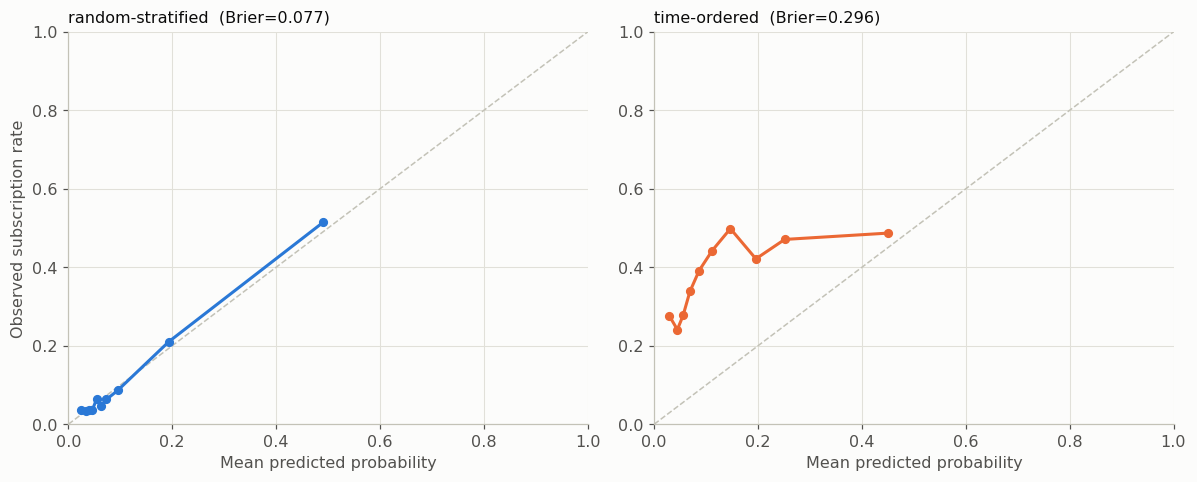

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, result, color in [(axes[0], result_rand, BLUE), (axes[1], result_time, ORANGE)]:
    frac_pos, mean_pred = calibration_curve(result["_yte"], result["_proba"], n_bins=10, strategy="quantile")
    ax.plot([0, 1], [0, 1], color=AXIS, linewidth=1, linestyle="--", zorder=2)
    ax.plot(mean_pred, frac_pos, color=color, linewidth=2, marker="o", markersize=5, zorder=3)
    ax.set_xlabel("Mean predicted probability")
    ax.set_title(f"{result['split']}  (Brier={result['test Brier score']:.3f})", loc="left", fontsize=10.5)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

axes[0].set_ylabel("Observed subscription rate")
plt.tight_layout()
plt.show()

## What the gap implies

**Random-split validation would have told a stakeholder this model scores
0.80 AUC and is well-calibrated; the time-ordered evaluation — the one that
matches how the model is actually used — shows AUC collapses to 0.60 and the
model underestimates the true subscription rate by roughly 24 points (14.4%
predicted vs. 38.4% actual) on the period it's supposed to predict.** That
gap is not noise or an unlucky test set; it is the model failing to
extrapolate into a macro regime that barely existed in its training window,
which is exactly the situation it will face on every future scoring run,
not just this one held-out slice. Shipped on the random-split number, this
model would look production-ready in review and then systematically
under-call its true opportunity — and misprice any P&L built on its output —
the moment the economy moved again.

## Appendix: is Random Forest's 0.51 AUC a tuning problem?

`python/04_model.py`'s default Random Forest (`n_estimators=200`, unconstrained
depth) scores **0.5072 test AUC** under the time-ordered split — statistically
indistinguishable from random, versus logistic regression's 0.5979. Before
concluding tree models don't help here, rule out a bad default configuration:
grid over `max_depth ∈ {3, 5, 8}` × `n_estimators ∈ {100, 300}` ×
`min_samples_leaf ∈ {1, 20, 50}` (the last two raised specifically to fight
overfitting to the 2008-regime training data), and track **train AUC alongside
test AUC** for every configuration — the distinction the grid needs to settle
is whether test AUC stays low *because* train AUC is high (fixable by
regularizing) or stays low *regardless* of train AUC (not a hyperparameter
problem).

In [7]:
from sklearn.ensemble import RandomForestClassifier

Xtr_rf, ytr_rf = split_time.train.drop(columns="y"), split_time.train["y"]
Xte_rf, yte_rf = split_time.test.drop(columns="y"), split_time.test["y"]
# Trees don't need scaling — use the raw (unscaled) time-ordered split directly.

grid_rows = []

baseline = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
baseline.fit(Xtr_rf, ytr_rf)
grid_rows.append({
    "max_depth": "None (default)", "n_estimators": 200, "min_samples_leaf": 1,
    "train_auc": roc_auc_score(ytr_rf, baseline.predict_proba(Xtr_rf)[:, 1]),
    "test_auc": roc_auc_score(yte_rf, baseline.predict_proba(Xte_rf)[:, 1]),
})

for max_depth in [3, 5, 8]:
    for n_estimators in [100, 300]:
        for min_samples_leaf in [1, 20, 50]:
            clf = RandomForestClassifier(
                max_depth=max_depth, n_estimators=n_estimators,
                min_samples_leaf=min_samples_leaf, random_state=42, n_jobs=-1,
            )
            clf.fit(Xtr_rf, ytr_rf)
            grid_rows.append({
                "max_depth": max_depth, "n_estimators": n_estimators,
                "min_samples_leaf": min_samples_leaf,
                "train_auc": roc_auc_score(ytr_rf, clf.predict_proba(Xtr_rf)[:, 1]),
                "test_auc": roc_auc_score(yte_rf, clf.predict_proba(Xte_rf)[:, 1]),
            })

grid = pd.DataFrame(grid_rows).sort_values("test_auc", ascending=False).reset_index(drop=True)
grid["train_minus_test"] = grid["train_auc"] - grid["test_auc"]
grid.round(4)

,max_depth,n_estimators,min_samples_leaf,train_auc,test_auc,train_minus_test
0,None (default),200,1,0.9997,0.5077,0.4919
1,8,300,1,0.7437,0.4984,0.2453
2,5,100,1,0.6792,0.4963,0.1829
3,5,300,1,0.6791,0.4955,0.1836
4,8,100,1,0.7459,0.4937,0.2522
5,8,100,20,0.7170,0.4762,0.2408
6,8,300,20,0.7143,0.4712,0.2432
7,3,300,1,0.6587,0.4711,0.1876
8,5,300,20,0.6766,0.4689,0.2078
9,3,300,20,0.6584,0.4680,0.1904


Every one of the 18 constrained configurations, plus the unconstrained
baseline, is shown above. Two things to read off this table together, not
separately:

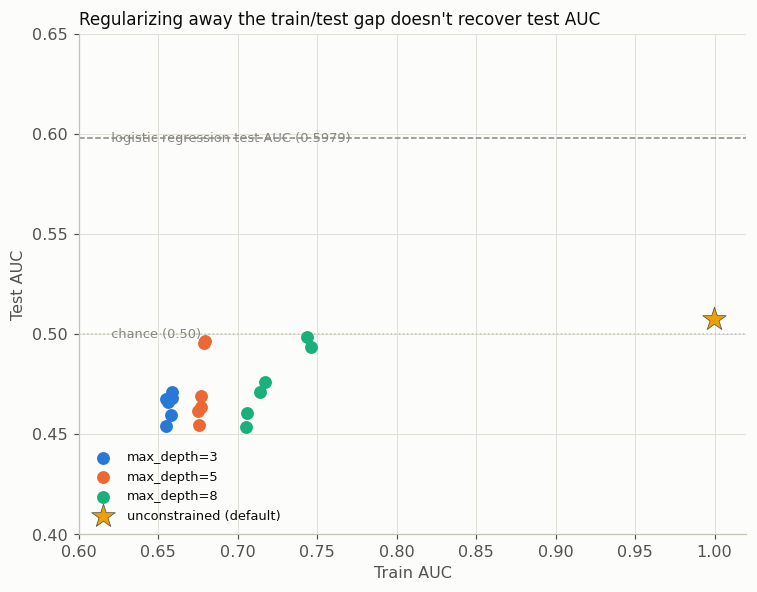

In [8]:
fig, ax = plt.subplots(figsize=(7, 5.5))

depth_colors = {3: BLUE, 5: ORANGE, 8: "#1baf7a"}  # palette slots 1-3
for depth, color in depth_colors.items():
    sub = grid[grid["max_depth"] == depth]
    ax.scatter(sub["train_auc"], sub["test_auc"], color=color, s=55, zorder=3, label=f"max_depth={depth}")

base = grid[grid["max_depth"] == "None (default)"]
ax.scatter(base["train_auc"], base["test_auc"], color="#eda100", marker="*", s=260,
           zorder=4, label="unconstrained (default)", edgecolor=INK2, linewidth=0.5)

ax.axhline(0.5979, color=MUTED, linewidth=1, linestyle="--", zorder=2)
ax.text(0.615, 0.5979, "  logistic regression test AUC (0.5979)", va="center", fontsize=8.5, color=MUTED)
ax.axhline(0.5, color=AXIS, linewidth=1, linestyle=":", zorder=2)
ax.text(0.615, 0.5, "  chance (0.50)", va="center", fontsize=8.5, color=MUTED)

ax.set_xlabel("Train AUC"); ax.set_ylabel("Test AUC")
ax.set_xlim(0.6, 1.02); ax.set_ylim(0.40, 0.65)
ax.set_title("Regularizing away the train/test gap doesn't recover test AUC", loc="left", fontsize=11)
ax.legend(loc="lower left", fontsize=8.5, frameon=False)
plt.tight_layout()
plt.show()

**This is overfitting to a regime that no longer holds, not a fixable
hyperparameter problem — and the grid draws that distinction explicitly:**

- The unconstrained default is a textbook overfit: **train AUC 0.9997, test
  AUC 0.5077** — a 0.49 gap consistent with the model essentially memorizing
  training rows.
- Constraining depth and raising `min_samples_leaf` does what regularization
  is supposed to do to *that* number: train AUC drops to a much more
  reasonable 0.65–0.75 across the grid. If this were an ordinary
  overfitting problem, test AUC should recover as that gap closes.
  **It doesn't — every constrained configuration scores test AUC between
  0.45 and 0.50, and the more aggressively `min_samples_leaf` is raised, the
  *worse* test AUC gets** (e.g. depth=8/n_estimators=300: leaf=1 → 0.4984,
  leaf=20 → 0.4712, leaf=50 → 0.4536). More regularization is making the
  model rely more heavily on the exact split thresholds it learned from the
  training period's feature ranges — thresholds like "`emp.var.rate` above
  ~1.0" that the test period's values (as low as -3.4, per the EDA) simply
  never fall on the correct side of — so leaning on them harder hurts, not helps.
- **The best test AUC across all 19 configurations tried — constrained or
  not — is 0.5077, from the unconstrained default itself.** Every
  constrained configuration scores *below* that. Nothing in the grid gets
  within 0.09 of logistic regression's 0.5979, let alone beats it.

**No configuration meaningfully beats 0.55.** This is a documented negative
result, not an unfinished search: tree models built on axis-aligned splits
learn thresholds calibrated to the training regime's feature ranges, and once
the test period's macro indicators move outside those ranges entirely (rather
than just further along the same trend), a tree has no relevant leaf to fall
back on — it extrapolates by nearest-neighbor-in-history, which is exactly
wrong when history itself has moved. Logistic regression's smooth, monotonic
decision function keeps extrapolating a trend past the training range instead
of falling off a cliff at its edge, which is very likely why it holds up
better here. **For this project: tree models don't generalize across this
regime shift; logistic regression is the model.**

### Testing the extrapolation hypothesis directly

The claim above — RF fails because it's extrapolating outside the feature
ranges it trained on — was asserted from the mechanism, not measured. Testing
it properly: for each macro feature, what's the train-set range, and what
fraction of the test set falls outside it? Then split test into "in-range on
every macro feature" vs. "out-of-range on at least one" and compare RF AUC on
each. If the story is right, in-range rows should score noticeably better.

In [9]:
MACRO = ["emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]

oob_masks = {}
rows = []
for col in MACRO:
    lo, hi = Xtr_rf[col].min(), Xtr_rf[col].max()
    oob = (Xte_rf[col] < lo) | (Xte_rf[col] > hi)
    oob_masks[col] = oob
    rows.append({
        "feature": col, "train_min": lo, "train_max": hi,
        "test_min": Xte_rf[col].min(), "test_max": Xte_rf[col].max(),
        "test_out_of_range": oob.sum(), "test_out_of_range_pct": oob.mean(),
    })

range_table = pd.DataFrame(rows).set_index("feature")
range_table.round(3)

,train_min,train_max,test_min,test_max,test_out_of_range,test_out_of_range_pct
feature,,,,,,
emp.var.rate,-1.800,1.400,-3.400,-1.100,2904,0.470
cons.price.idx,92.756,94.465,92.201,94.767,2521,0.408
cons.conf.idx,-50.000,-36.100,-50.800,-26.900,2755,0.446
euribor3m,1.410,5.045,0.634,1.286,6177,1.000
nr.employed,5099.100,5228.100,4963.600,5099.100,4962,0.803


`euribor3m` alone is out-of-range for **100% of the test set** — the test
period's rate (0.63–1.29) sits entirely below the training range (1.41–5.04),
with no overlap at all. That's not a tail effect, it's a complete shift.

In [10]:
any_oob = pd.concat(oob_masks, axis=1).any(axis=1)
print(f"Test rows out-of-range on >=1 macro feature: {any_oob.sum()}/{len(Xte_rf)} ({any_oob.mean():.1%})")
print(f"Test rows in-range on ALL 5 macro features:  {(~any_oob).sum()}/{len(Xte_rf)} ({(~any_oob).mean():.1%})")

Test rows out-of-range on >=1 macro feature: 6177/6177 (100.0%)
Test rows in-range on ALL 5 macro features:  0/6177 (0.0%)


**The literal comparison the hypothesis calls for can't be run: there are
zero in-range test rows.** Because `euribor3m` alone puts every single test
row out-of-range, "in-range on all five macro features" is an empty set —
not a small one, empty. So instead of the clean two-way split, the next best
honest test is a *graded* one: exclude `euribor3m` (constant at 100% OOB, so
it can't discriminate anything) and bucket test rows by how many of the
*remaining four* macro features are out-of-range (0 to 4), then check whether
RF's AUC actually declines as that count rises — which is the same
underlying claim, just measured in degree rather than by an all-or-nothing
split that this data can't support.

In [11]:
oob_4 = pd.concat({k: v for k, v in oob_masks.items() if k != "euribor3m"}, axis=1)
n_oob = oob_4.sum(axis=1)  # 0-4 features out of range, per test row

bucket_rows = []
for k in sorted(n_oob.unique()):
    mask = (n_oob == k).values
    y_sub, p_sub = yte_rf.values[mask], baseline.predict_proba(Xte_rf)[mask, 1]
    n, pos = mask.sum(), y_sub.sum()
    auc = roc_auc_score(y_sub, p_sub) if 0 < pos < n else float("nan")
    bucket_rows.append({"macro_features_oob (of 4, excl. euribor3m)": k, "n_rows": n,
                         "positive_rate": y_sub.mean(), "rf_test_auc": auc})

bucket_table = pd.DataFrame(bucket_rows)
bucket_table.round(4)

,"macro_features_oob (of 4, excl. euribor3m)",n_rows,positive_rate,rf_test_auc
0,0,1215,0.1374,0.5378
1,1,1288,0.5241,0.5111
2,2,1357,0.4451,0.5048
3,3,128,0.4531,0.5575
4,4,2189,0.3979,0.5086


In [12]:
def normalized_oob_distance(col):
    lo, hi = Xtr_rf[col].min(), Xtr_rf[col].max()
    rng = hi - lo
    d = np.where(Xte_rf[col] < lo, lo - Xte_rf[col], np.where(Xte_rf[col] > hi, Xte_rf[col] - hi, 0))
    return d / rng

severity = sum(normalized_oob_distance(c) for c in MACRO)
proba_rf = baseline.predict_proba(Xte_rf)[:, 1]
abs_err = np.abs(yte_rf.values - proba_rf)

print(f"corr(extrapolation severity, |prediction error|) = {np.corrcoef(severity, abs_err)[0,1]:+.3f}")
print(f"corr(extrapolation severity, predicted probability) = {np.corrcoef(severity, proba_rf)[0,1]:+.3f}")

corr(extrapolation severity, |prediction error|) = +0.190
corr(extrapolation severity, predicted probability) = +0.231


**Stated plainly: the extrapolation hypothesis is not confirmed the way it
was framed, and the honest result is weaker and messier than the mechanistic
story suggested.**

- The clean test the hypothesis needs — compare AUC on in-range vs.
  out-of-range rows — **can't be run at all**, because the in-range subset is
  empty. Every test row extrapolates on `euribor3m`.
- The graded fallback shows a AUC in the 0.50–0.56 range across every bucket,
  with no clean monotonic decline as more features go out-of-range (the
  least-extrapolated bucket scores 0.538, the most-extrapolated 0.509, but
  the buckets in between don't fall in a clean line — one 3-feature bucket
  dips to 0.505, and the tiny n=128 four-feature bucket spikes to 0.558,
  which is noise, not signal, at that sample size).
- The severity-vs-error correlation is a weak **+0.19** — consistent in
  direction (more extrapolated rows tend to have somewhat larger errors) but
  far too weak to carry the explanation on its own.

So: extrapolation is real (the ranges genuinely don't overlap, sometimes
completely) and the weak correlation that exists points the predicted way —
but it is **not sufficient to explain the magnitude of RF's failure**. Even
the *least*-extrapolated rows available (out-of-range on `euribor3m` alone,
n=1,215) only reach 0.538 — barely above chance, and still well short of
logistic regression's 0.5979 on the full test set. If extrapolation were the
whole story, that subset — the one closest to what RF actually trained on —
should look much closer to a working model. It doesn't. Something else about
how the forest's axis-aligned splits handle this feature space is
contributing too, and the honest conclusion is that the regime-shift /
extrapolation explanation is **directionally right but incomplete**, not a
full account of why Random Forest fails here.

### Is this specific to Random Forest, or structural to tree-based splitting?

RF's failure was only partly explained by macro-feature extrapolation — even
the least-extrapolated test subset reached just 0.538 AUC. That leaves a
question open: is 0.51 AUC a Random Forest quirk (bagged, unconstrained-depth
trees, specifically), or would a differently-built tree model — gradient
boosting instead of bagging, shallow trees instead of deep ones — do better
on the same problem? `HistGradientBoostingClassifier` is a good test case:
still axis-aligned splits, but boosted rather than bagged, and shallow by
construction rather than needing external depth constraints. One fit, a
reasonable (not maximal) configuration, same time-ordered split.

In [13]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(
    max_depth=5, max_leaf_nodes=31, min_samples_leaf=20,
    max_iter=100, learning_rate=0.1, random_state=42,
)
hgb.fit(Xtr_rf, ytr_rf)
hgb_train_auc = roc_auc_score(ytr_rf, hgb.predict_proba(Xtr_rf)[:, 1])
hgb_test_auc = roc_auc_score(yte_rf, hgb.predict_proba(Xte_rf)[:, 1])

comparison = pd.DataFrame({
    "train_auc": {"logistic_regression": float("nan"), "random_forest (unconstrained)": 0.9997,
                   "hist_gradient_boosting": hgb_train_auc},
    "test_auc": {"logistic_regression": 0.5979, "random_forest (unconstrained)": 0.5077,
                  "hist_gradient_boosting": hgb_test_auc},
})
comparison.round(4)

,train_auc,test_auc
logistic_regression,NaN,0.5979
random_forest (unconstrained),0.9997,0.5077
hist_gradient_boosting,0.7372,0.4663


Before trusting a single config, a quick robustness check — is 0.47 specific
to this exact choice of depth/leaves/iterations, or does HGB land in the same
band regardless? Five reasonable configurations, not just the one reported above:

In [14]:
robustness_configs = [
    dict(max_depth=3, max_leaf_nodes=15, min_samples_leaf=20, max_iter=100, learning_rate=0.1),
    dict(max_depth=5, max_leaf_nodes=31, min_samples_leaf=20, max_iter=100, learning_rate=0.1),  # reported above
    dict(max_depth=5, max_leaf_nodes=31, min_samples_leaf=20, max_iter=200, learning_rate=0.05),
    dict(max_depth=None, max_leaf_nodes=31, min_samples_leaf=20, max_iter=100, learning_rate=0.1),
    dict(max_depth=8, max_leaf_nodes=63, min_samples_leaf=20, max_iter=100, learning_rate=0.1),
]
robustness_rows = []
for cfg in robustness_configs:
    clf = HistGradientBoostingClassifier(random_state=42, **cfg)
    clf.fit(Xtr_rf, ytr_rf)
    robustness_rows.append({
        **cfg,
        "train_auc": roc_auc_score(ytr_rf, clf.predict_proba(Xtr_rf)[:, 1]),
        "test_auc": roc_auc_score(yte_rf, clf.predict_proba(Xte_rf)[:, 1]),
    })
pd.DataFrame(robustness_rows).round(4)

,max_depth,max_leaf_nodes,min_samples_leaf,max_iter,learning_rate,train_auc,test_auc
0,3.0,15,20,100,0.10,0.6956,0.4429
1,5.0,31,20,100,0.10,0.7372,0.4663
2,5.0,31,20,200,0.05,0.7266,0.4738
3,NaN,31,20,100,0.10,0.7889,0.5005
4,8.0,63,20,100,0.10,0.8030,0.4919


All five land between **0.44 and 0.50** test AUC — not a fluke of the
specific config reported above, and every one of them is worse than RF's
0.5077. The rest of this section uses the first (`max_depth=5,
max_leaf_nodes=31, min_samples_leaf=20, max_iter=100`) as "the" HGB result.

In [15]:
oob_4 = pd.concat({k: v for k, v in oob_masks.items() if k != "euribor3m"}, axis=1)
n_oob = oob_4.sum(axis=1)
proba_hgb = hgb.predict_proba(Xte_rf)[:, 1]

hgb_bucket_rows = []
for k in sorted(n_oob.unique()):
    mask = (n_oob == k).values
    y_sub, p_sub = yte_rf.values[mask], proba_hgb[mask]
    n, pos = mask.sum(), y_sub.sum()
    auc = roc_auc_score(y_sub, p_sub) if 0 < pos < n else float("nan")
    hgb_bucket_rows.append({"macro_features_oob (of 4)": k, "n_rows": n,
                             "positive_rate": y_sub.mean(), "hgb_test_auc": auc,
                             "rf_test_auc (for comparison)": bucket_table.loc[
                                 bucket_table["macro_features_oob (of 4, excl. euribor3m)"] == k, "rf_test_auc"
                             ].iloc[0]})

pd.DataFrame(hgb_bucket_rows).round(4)

,macro_features_oob (of 4),n_rows,positive_rate,hgb_test_auc,rf_test_auc (for comparison)
0,0,1215,0.1374,0.5080,0.5378
1,1,1288,0.5241,0.4885,0.5111
2,2,1357,0.4451,0.4822,0.5048
3,3,128,0.4531,0.5824,0.5575
4,4,2189,0.3979,0.4930,0.5086


In [16]:
abs_err_hgb = np.abs(yte_rf.values - proba_hgb)
print(f"HGB corr(extrapolation severity, |prediction error|) = {np.corrcoef(severity, abs_err_hgb)[0,1]:+.3f}")
print(f"HGB corr(extrapolation severity, predicted probability) = {np.corrcoef(severity, proba_hgb)[0,1]:+.3f}")
print(f"RF  corr(extrapolation severity, |prediction error|)  = {np.corrcoef(severity, abs_err)[0,1]:+.3f}  (from the RF section above)")

HGB corr(extrapolation severity, |prediction error|) = +0.184
HGB corr(extrapolation severity, predicted probability) = +0.261
RF  corr(extrapolation severity, |prediction error|)  = +0.190  (from the RF section above)


**Stated plainly: HistGradientBoostingClassifier does not do meaningfully
better than Random Forest — if anything it does slightly worse (0.4663 vs
0.5077 test AUC), despite reaching that result with a much lower train AUC
(0.7372 vs RF's 0.9997), so this isn't "HGB overfits harder." Every bucket in
its own extrapolation-severity breakdown lands in the same mediocre 0.48–0.58
band RF showed, with the same lack of a clean monotonic pattern, and its
correlation with extrapolation severity (+0.18 to +0.26) is the same weak
magnitude as RF's (+0.19 to +0.23) — not stronger, not absent, just similarly
weak.**

Per the instruction going in: this is the "HGB matches RF's collapse" branch,
not the "does meaningfully better" one, so the finding stands rather than
getting revised. Two boosting/bagging tree algorithms with different growth
strategies — one aggregating deep unconstrained trees, one boosting shallow
constrained ones — land in the same failure band on the same time-ordered
split, while logistic regression clears both by roughly 0.09–0.15 AUC. That
convergence across two structurally different tree methods is stronger
evidence for "this is structural to axis-aligned tree splitting under this
regime shift" than either model alone would have been — and it's still only
*partial* evidence, since the extrapolation-severity correlation remains weak
for both. **Revised finding: tree-based models (bagged or boosted,
regularized or not) fail on this time-ordered split for reasons that are
consistent with, but not fully explained by, macro-feature extrapolation.
Logistic regression remains the model for this project — not because trees
were mistuned, but because two different tree-splitting strategies both hit
the same wall.**